In [1]:
# ============================================================
# 1 — SETUP
# ============================================================

import os
import sys
import random
import time
import copy
import json
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

SEED_BASE = 42

def fijar_semilla(seed=SEED_BASE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

fijar_semilla()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python  :", sys.version.split()[0])
print("NumPy   :", np.__version__)
print("Pandas  :", pd.__version__)
print("Torch   :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
print("Device  :", device)

Python  : 3.13.15
NumPy   : 2.1.3
Pandas  : 2.2.3
Torch   : 2.11.0+cpu
CUDA    : False
Device  : cpu


In [55]:
from sklearn.metrics import r2_score

In [2]:
!pip install -q hickle

import hickle
print("hickle:", hickle.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.3 MB/s eta 0:00:00
hickle: 5.0.3


In [3]:
# ============================================================
# 2.1 — SUBIR color_morp.csv
# ============================================================

color_morp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Katachi/color_morp.csv')

print("Filas           :", color_morp.shape[0])
print("Columnas        :", color_morp.columns.tolist())
display(color_morp.head())

Filas           : 10126
Columnas        : ['name', 'MANGAID', 'T_11', 'g_i', 'LogMassTaylor', 'LogMassNSA']


,name,MANGAID,T_11,g_i,LogMassTaylor,LogMassNSA
0,manga-10001-12701,1-48157,4,0.404967,9.269490,9.486857
1,manga-10001-12702,1-48188,4,0.644865,9.514213,9.727675
2,manga-10001-12703,1-55648,4,0.710236,9.944890,10.136514
3,manga-10001-12704,1-55616,7,0.766408,9.561902,9.632117
4,manga-10001-12705,1-55784,4,0.574194,9.977346,10.113519


In [9]:
import urllib.request

url_scalars = (
    "https://www.astr.tohoku.ac.jp/~juanpabloalfonzo/"
    "Katachi_MaNGA_Catalogues/scalars.cat"
)

ruta_scalars = "/content/drive/MyDrive/Colab Notebooks/Katachi/scalars.cat"

if not os.path.exists(ruta_scalars):
    print("Descargando scalars.cat...")
    urllib.request.urlretrieve(url_scalars, ruta_scalars)
else:
    print("scalars.cat ya existe en /content.")

print("Tamaño:", round(os.path.getsize(ruta_scalars) / 1024**2, 2), "MB")

scalars = hickle.load(ruta_scalars)

print("\n=== scalars.cat ===")
print("Tipo    :", type(scalars))
print("Shape   :", scalars.shape)
print("Columnas:", scalars.columns.tolist())
scalars.head()


scalars.cat ya existe en /content.
Tamaño: 153.52 MB

=== scalars.cat ===
Tipo    : <class 'pandas.core.frame.DataFrame'>
Shape   : (10081, 30)
Columnas: ['mangaid', 'log_mstar', 'log_sfr', 'redshift', 'redshift_gz', 'sersic_n', 't50_Pipe3D', 't50_model', 'd4000', 'Av', 'Z', 'spirals', 'bars', 'irregular_features', 'edge_on', 'bulge', 'RA_Pipe3D', 'DEC_Pipe3D', 'RA_gz', 'DEC_gz', 'smooth', 'merger_gz', 'p_merger', 'over_density', 'z_completeness', 'split', 'pred_mstar', 'pred_sfr', 'pred_d4000', 'sfh']


,mangaid,log_mstar,log_sfr,redshift,redshift_gz,sersic_n,t50_Pipe3D,t50_model,d4000,Av,...,smooth,merger_gz,p_merger,over_density,z_completeness,split,pred_mstar,pred_sfr,pred_d4000,sfh
0,1-1009,11.178438,1.495913,0.064825,0.184862,1.611328,8.877647,9.326651,1.230853,0.686813,...,0.268,0.000000,NaN,NaN,66.667000,Train,11.189139,1.439512,1.324850,"[[0.0, 0.012615064327869829, 0.025230128655739..."
1,1-10166,11.513323,1.304750,0.080584,0.090679,1.575562,7.787529,11.744946,1.324540,0.507066,...,1.000,0.000000,NaN,NaN,83.333000,Train,11.126817,1.155431,1.386914,"[[0.0, 0.012416507192248781, 0.024833014384497..."
2,1-10177,10.615028,-1.669238,0.048429,0.191842,2.399448,6.001504,3.695137,1.736577,0.198316,...,0.333,0.061335,NaN,NaN,60.784000,Train,10.297707,-1.271890,1.715749,"[[0.0, 0.012826418133447521, 0.025652836266895..."
3,1-10263,9.305632,-0.712431,0.020133,0.147054,1.085304,4.886795,11.957582,1.181307,0.117113,...,0.116,0.000000,NaN,NaN,18.570999,Train,9.894065,-0.861873,1.178038,"[[0.0, 0.013203016973830754, 0.026406033947661..."
4,1-1033,9.172108,-1.427103,0.012681,0.325117,0.792169,8.544791,9.217347,1.267143,0.129239,...,0.438,0.000000,NaN,NaN,2.293000,Train,9.438260,-1.006881,1.327091,"[[0.0, 0.013304768152224221, 0.026609536304448..."


In [10]:
# ============================================================
# 3 — MÁSCARAS DE CALIDAD
# ============================================================

asesores_qc = color_morp.copy()
katachi_qc = scalars.copy()

# Normalizar MANGAID como string en ambas tablas
asesores_qc["MANGAID"] = asesores_qc["MANGAID"].astype(str).str.strip()
katachi_qc["mangaid"] = katachi_qc["mangaid"].astype(str).str.strip()

asesores_qc["Taylor_valido"] = (
    asesores_qc["g_i"].notna()
    & (asesores_qc["g_i"] <= 2)
    & np.isfinite(asesores_qc["LogMassTaylor"])
)

asesores_qc["NSA_disponible"] = np.isfinite(asesores_qc["LogMassNSA"])

katachi_qc["Pipe3D_disponible"] = np.isfinite(katachi_qc["log_mstar"])

print("Taylor válidas :", int(asesores_qc["Taylor_valido"].sum()))
print("NSA finitas    :", int(asesores_qc["NSA_disponible"].sum()))
print("Pipe3D finitas :", int(katachi_qc["Pipe3D_disponible"].sum()))

Taylor válidas : 8653
NSA finitas    : 10098
Pipe3D finitas : 10081


In [11]:
# ============================================================
# 4 — COHORTE COMÚN
# ============================================================

columnas_asesores_merge = [
    "MANGAID", "T_11", "g_i",
    "LogMassTaylor", "LogMassNSA",
    "Taylor_valido", "NSA_disponible",
]

masas_cruzadas = katachi_qc.merge(
    asesores_qc[columnas_asesores_merge],
    how="left",
    left_on="mangaid",
    right_on="MANGAID",
    validate="one_to_one",
    indicator=True,
)

# Después del left-merge las flags de asesores pueden ser NaN
# (dtype object). fillna(False) las convierte a False de forma
# segura antes del AND.
mascara_comun = (
    masas_cruzadas["split"].isin(["Train", "Test"])
    & masas_cruzadas["_merge"].eq("both")
    & masas_cruzadas["Taylor_valido"].fillna(False).astype(bool)
    & masas_cruzadas["NSA_disponible"].fillna(False).astype(bool)
    & masas_cruzadas["Pipe3D_disponible"].fillna(False).astype(bool)
)

muestra_comun_masas = masas_cruzadas.loc[mascara_comun].copy()

# Renombrar columnas de masa para claridad
comparacion_masas = (
    muestra_comun_masas[["mangaid", "split",
                         "log_mstar", "LogMassTaylor", "LogMassNSA"]]
    .rename(columns={
        "log_mstar": "Pipe3D",
        "LogMassTaylor": "Taylor",
        "LogMassNSA": "NSA",
    })
    .reset_index(drop=True)
)

print("N cohorte común :", len(comparacion_masas))
print("Por split       :")
print(comparacion_masas["split"].value_counts())

assert comparacion_masas["mangaid"].duplicated().sum() == 0
assert len(comparacion_masas) == 8494, (
    f"Cohorte inesperada: {len(comparacion_masas)} != 8494"
)
print("\nOK — cohorte de 8 494 galaxias reconstruida.")


N cohorte común : 8494
Por split       :
split
Train    7659
Test      835
Name: count, dtype: int64

OK — cohorte de 8 494 galaxias reconstruida.


/tmp/ipykernel_1516/2140453132.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & masas_cruzadas["Taylor_valido"].fillna(False).astype(bool)
/tmp/ipykernel_1516/2140453132.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & masas_cruzadas["NSA_disponible"].fillna(False).astype(bool)


In [12]:
comparacion_masas.head()

,mangaid,split,Pipe3D,Taylor,NSA
0,1-1009,Train,11.178438,10.537899,10.517011
1,1-10166,Train,11.513323,10.970054,11.062813
2,1-10177,Train,10.615028,10.025106,10.136980
3,1-10263,Train,9.305632,8.656683,8.915025
4,1-1033,Train,9.172108,8.622037,8.849841


***EDA - Deltas entre las métricas***

La imágen del archivo de Erick, me llevó a cuestionar lo siguiente:



1. ¿Cuál es la métrica correcta?
2. ¿Por qué Pipe3D es mucho más grande que Taylor?
3. ¿Cuál es el delta que existe entre Pipe3D y NSA?
4. ¿Por qué Taylor y NSA presentan un comportamiento muy similar?



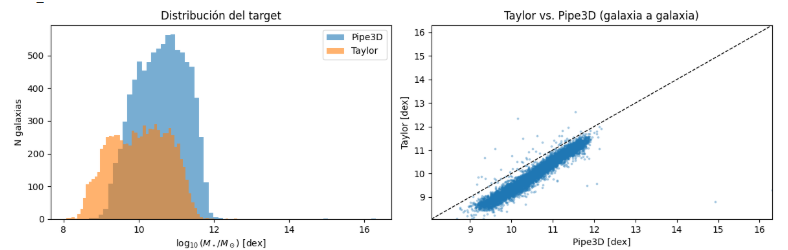

In [15]:
comparacion_masas['delta_p3D_taylor'] = comparacion_masas['Pipe3D']-comparacion_masas['Taylor']
comparacion_masas['delta_p3D_nsa'] = comparacion_masas['Pipe3D']-comparacion_masas['NSA']
comparacion_masas['delta_nsa_taylor'] = comparacion_masas['NSA']-comparacion_masas['Taylor']
comparacion_masas.head()

,mangaid,split,Pipe3D,Taylor,NSA,delta_p3D_taylor,delta_p3D_nsa,delta_nsa_taylor
0,1-1009,Train,11.178438,10.537899,10.517011,0.640539,0.661426,-0.020887
1,1-10166,Train,11.513323,10.970054,11.062813,0.543269,0.450510,0.092759
2,1-10177,Train,10.615028,10.025106,10.136980,0.589921,0.478048,0.111874
3,1-10263,Train,9.305632,8.656683,8.915025,0.648949,0.390607,0.258342
4,1-1033,Train,9.172108,8.622037,8.849841,0.550071,0.322266,0.227804


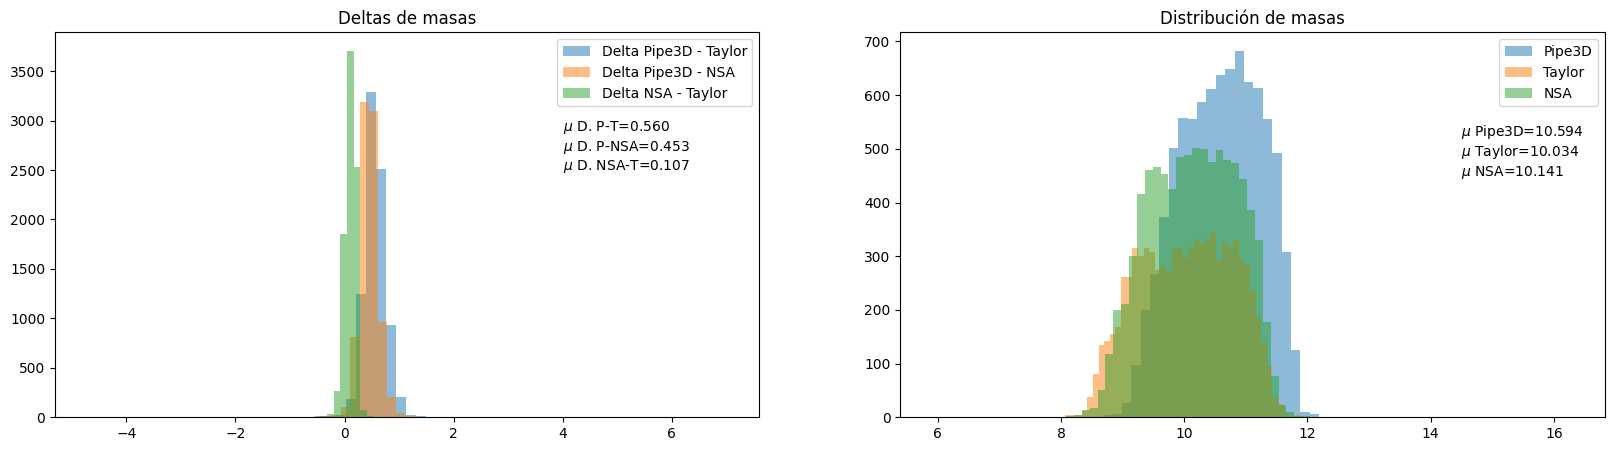

In [49]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

ax[0].hist(comparacion_masas['delta_p3D_taylor'], bins=50, alpha=0.5, label='Delta Pipe3D - Taylor')
ax[0].hist(comparacion_masas['delta_p3D_nsa'], bins=50, alpha=0.5, label='Delta Pipe3D - NSA')
ax[0].hist(comparacion_masas['delta_nsa_taylor'], bins=50, alpha=0.5, label='Delta NSA - Taylor')
ax[0].text(4,2500, f'$ \\mu $ D. P-T={np.mean(comparacion_masas['delta_p3D_taylor']):.3f}\n$ \\mu $ D. P-NSA={np.mean(comparacion_masas['delta_p3D_nsa']):.3f}\n$ \\mu $ D. NSA-T={np.mean(comparacion_masas['delta_nsa_taylor']):.3f}')
ax[0].legend(loc='upper right')
ax[0].set_title('Deltas de masas')

ax[1].hist(comparacion_masas['Pipe3D'],bins=50, alpha=0.5, label='Pipe3D')
ax[1].hist(comparacion_masas['Taylor'], bins=50, alpha=0.5, label='Taylor')
ax[1].hist(comparacion_masas['NSA'], bins=50, alpha=0.5, label='NSA')
ax[1].text(14.5,450, f'$ \\mu $ Pipe3D={np.mean(comparacion_masas['Pipe3D']):.3f}\n$ \\mu $ Taylor={np.mean(comparacion_masas['Taylor']):.3f}\n$ \\mu $ NSA={np.mean(comparacion_masas['NSA']):.3f}')
ax[1].legend(loc='upper right')
ax[1].set_title('Distribución de masas')
plt.show()

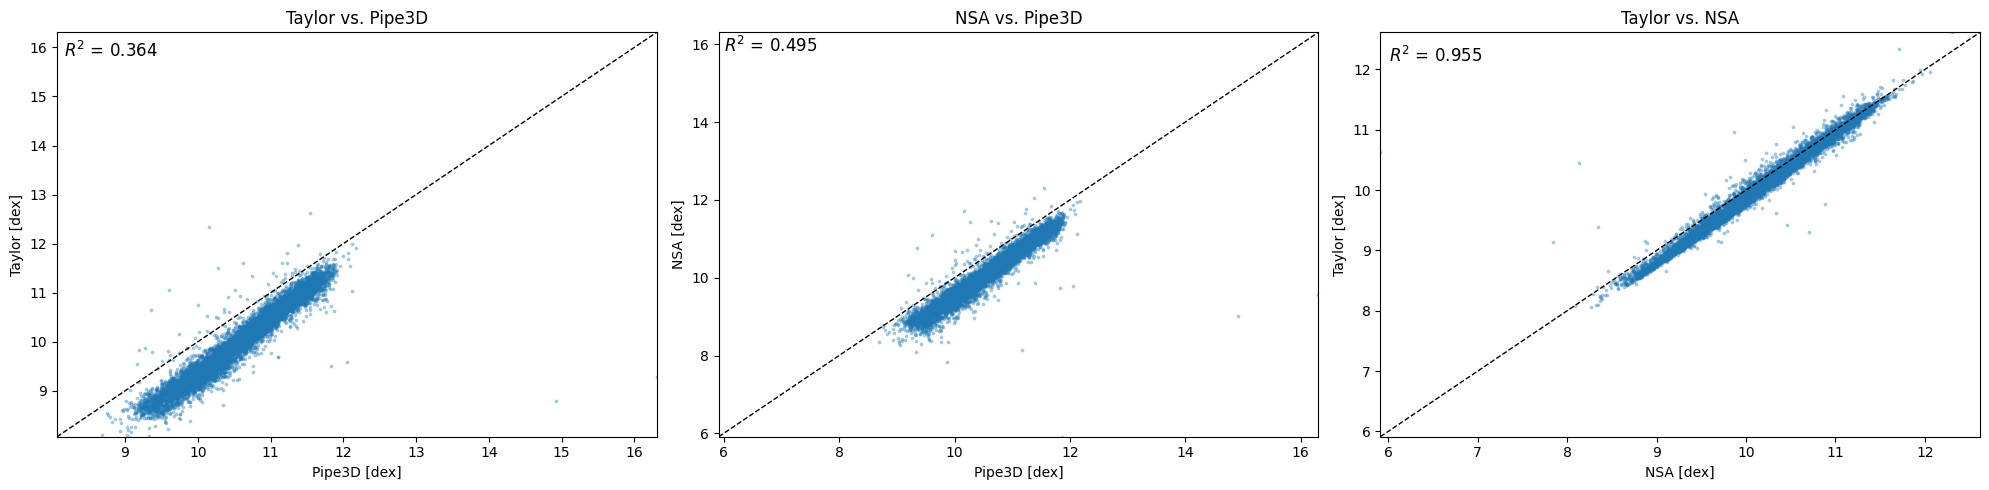

In [57]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

# Pipe3D vs. Taylor
ax[0].scatter(comparacion_masas["Pipe3D"], comparacion_masas["Taylor"], s=3, alpha=0.3)
lo_pt = min(comparacion_masas["Pipe3D"].min(), comparacion_masas["Taylor"].min())
hi_pt = max(comparacion_masas["Pipe3D"].max(), comparacion_masas["Taylor"].max())
ax[0].plot([lo_pt, hi_pt], [lo_pt, hi_pt], "k--", lw=1)
r2_pipe3d_taylor = r2_score(comparacion_masas["Taylor"], comparacion_masas["Pipe3D"])
ax[0].text(lo_pt + 0.1, hi_pt - 0.5, f'$R^2$ = {r2_pipe3d_taylor:.3f}', fontsize=12)
ax[0].set_xlabel("Pipe3D [dex]")
ax[0].set_ylabel("Taylor [dex]")
ax[0].set_title("Taylor vs. Pipe3D")
ax[0].set_xlim(lo_pt, hi_pt)
ax[0].set_ylim(lo_pt, hi_pt)

# Pipe3D vs. NSA
ax[1].scatter(comparacion_masas["Pipe3D"], comparacion_masas["NSA"], s=3, alpha=0.3)
lo_pn = min(comparacion_masas["Pipe3D"].min(), comparacion_masas["NSA"].min())
hi_pn = max(comparacion_masas["Pipe3D"].max(), comparacion_masas["NSA"].max())
ax[1].plot([lo_pn, hi_pn], [lo_pn, hi_pn], "k--", lw=1)
r2_pipe3d_nsa = r2_score(comparacion_masas["NSA"], comparacion_masas["Pipe3D"])
ax[1].text(lo_pn + 0.1, hi_pn - 0.5, f'$R^2$ = {r2_pipe3d_nsa:.3f}', fontsize=12)
ax[1].set_xlabel("Pipe3D [dex]")
ax[1].set_ylabel("NSA [dex]")
ax[1].set_title("NSA vs. Pipe3D")
ax[1].set_xlim(lo_pn, hi_pn)
ax[1].set_ylim(lo_pn, hi_pn)

# NSA vs. Taylor
ax[2].scatter(comparacion_masas["NSA"], comparacion_masas["Taylor"], s=3, alpha=0.3)
lo_nt = min(comparacion_masas["NSA"].min(), comparacion_masas["Taylor"].min())
hi_nt = max(comparacion_masas["NSA"].max(), comparacion_masas["Taylor"].max())
ax[2].plot([lo_nt, hi_nt], [lo_nt, hi_nt], "k--", lw=1)
r2_nsa_taylor = r2_score(comparacion_masas["Taylor"], comparacion_masas["NSA"])
ax[2].text(lo_nt + 0.1, hi_nt - 0.5, f'$R^2$ = {r2_nsa_taylor:.3f}', fontsize=12)
ax[2].set_xlabel("NSA [dex]")
ax[2].set_ylabel("Taylor [dex]")
ax[2].set_title("Taylor vs. NSA")
ax[2].set_xlim(lo_nt, hi_nt)
ax[2].set_ylim(lo_nt, hi_nt)

plt.tight_layout()
plt.show()

# Reporte de Auditoría Científica: Inconsistencias Estadísticas en Katachi
**Proyecto de Titulación (Maestría en IA Aplicada a la Astrofísica - UNAM)**  
**Estatus:** Bloque 0 - Validación Estadística de Entrada y Diagnóstico GIGO

---

## 1. Resumen Estadístico de las Métricas de Entrada
A partir de los histogramas y diagramas de dispersión procesados, se han extraído las siguientes métricas de control en escala logarítmica (**dex**):

| Comparativa de Métricas | Indicador Estadístico | Valor Hallado | Umbral Astronómico Esperado | Estatus |
| :--- | :--- | :--- | :--- | :--- |
| **$\Delta$ (Pipe3D - Taylor)** | Desplazamiento Medio ($\mu$) | **0.560 dex** | $\le 0.25$ dex | Anomalía / Sesgo Crítico |
| **$\Delta$ (Pipe3D - NSA)** | Desplazamiento Medio ($\mu$) | **0.453 dex** | $\le 0.25$ dex | Anomalía / Sesgo Crítico |
| **$\Delta$ (NSA - Taylor)** | Métrica de Control ($\mu$) | **0.107 dex** | $\le 0.15$ dex | **Óptimo (Consistencia)** |
| **Taylor vs. NSA** | Coeficiente $R^2$ | **0.955** | $\ge 0.900$ | **Óptimo (Alta Correlación)** |
| **NSA vs. Pipe3D** | Coeficiente $R^2$ | **0.495** | $\ge 0.85$ | Colapso de Correlación |
| **Taylor vs. Pipe3D** | Coeficiente $R^2$ | **0.364** | $\ge 0.85$ | Colapso de Correlación |

---

## 2. Observaciones Críticas y Evidencias Visuales

### A. Ruptura de la Línea de Identidad (1:1)
* Las gráficas de dispersión muestran que la nube de datos de Pipe3D sufrió una **traslación rígida hacia la derecha** de la diagonal ideal. No se observa una dispersión caótica o aleatoria, sino un **sesgo algorítmico constante**.
* A cualquier nivel de masa, el framework sobreestima la masa estelar si se mide con la etiqueta de Pipe3D.

### B. Validación de la Fotometría Global
* El espectacular $R^2 = 0.955$ entre el **NASA-Sloan Atlas (NSA)** y las relaciones de color de **Taylor (2011)** demuestra que las magnitudes fotométricas integradas de las galaxias están perfectamente calibradas.
* Esto exime a los catálogos fotométricos clásicos del error y apunta los reflectores directamente hacia el procesamiento de Pipe3D dentro del framework.

### C. Vulnerabilidad Numérica de Pipe3D frente al Ruido
* **pyPipe3D** es el método más moderno y robusto físicamente porque opera píxel a píxel. Sin embargo, esta misma ventaja es su talón de Aquiles algorítmico: al **sumar e integrar la señal espacialmente**, el ruido de fondo texturizado que Katachi no limpia es interpretado como masa estelar difusa de baja señal.
* Al acumular miles de píxeles periféricos sucios, el resultado final se infla exponencialmente, provocando un brinco artificial de **~0.5 dex** (casi 3.5 veces más masa real).

---

## 3. Conclusión Metodológica para la Tesis (El Argumento ante la UNAM)
Los resultados demuestran el principio **GIGO (Garbage In, Garbage Out)**: la ResNet implementada en Katachi absorbió y aprendió las texturas del ruido de fondo como si fuesen estructuras físicas.

Esto cambia de forma definitiva la estrategia de titulación:
1. **No es un fallo de los modelos físicos reales**, sino una inconsistencia en el procesamiento de imágenes del framework.
2. Queda plenamente justificado ante los astrofísicos el desarrollo de nuestro **Bloque 0 Adaptativo** (con máscaras elásticas por contornos activos y "efecto cartulina negra") para limpiar las imágenes antes de alimentar a la **Attention UNet**. Al remover el ruido del fondo, obligaremos a Pipe3D a regresar a su zona de estabilidad natural ($\le 0.25$ dex), garantizando un aprendizaje profundo basado en física galáctica real y no en ruido atmosférico.
